# Week 2 — backtesting fundamentals (Wednesday, 1 hour)

Six exercises on the governed backtest. Everything here calls **fc-10's own** `backtest` and TM rule registry:
the same threshold detection fires on, with no copy in this notebook. Every rate is against **PLANTED TRUTH**.

Run with `FC10_REPOSITORY` set (see `training/README.md`). Read `README.md` in this folder first.

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binomtest

sys.path.insert(0, str(Path.cwd().parents[1]))
from tools.tm_sim_source import load, fc10_module

tm_sim, metrics = load()
backtest = fc10_module("runtime.manufacturing.tuning.backtest")
registry = fc10_module("runtime.manufacturing.data_model.tm_rule_registry")
sns.set_theme(style="whitegrid")

pop = tm_sim.generate()
reg = registry.load_registry()
rule = registry.rule("high_value")
print(f"registry {reg['config_id']} v{reg['version']} · high_value threshold {rule['threshold']:,}")
print(f"population sha256 {pop.digest()[:16]}… · {len(pop.customers):,} customers · {sum(c.planted for c in pop.customers)} planted")

registry TM-RULE-REGISTRY v1.0.0 · high_value threshold 75,000


population sha256 7dc1ddbc19ba9e5e… · 5,000 customers · 200 planted


## Exercise 1 — read the committed baseline

`data-model/tuning/baseline_backtest.json` is **today's rules at today's thresholds**: the "before" for every later decision.
A test in fc-10 fails if it ever differs from a fresh run, so what you read here is what the code does now.

In [2]:
baseline = json.loads(backtest.BASELINE_PATH.read_text())
hv = baseline["rules"][0]
print("label source:", baseline["label_source"], "·", baseline["note"])
pd.Series({k: hv[k] for k in ("threshold", "alerts", "tp", "fp", "fn", "precision", "recall", "lift")})

label source: PLANTED_TRUTH · Rates are against planted truth in a synthetic population, not SAR outcomes.


threshold    75000.000000
alerts         679.000000
tp             110.000000
fp             569.000000
fn              90.000000
precision        0.162003
recall           0.550000
lift             4.050074
dtype: float64

## Exercise 2 — the curriculum's threshold table

Alert count, true positives and precision at £25k, £50k, £75k and £100k. The backtest evaluates each
variant of the **registered** rule, so the only thing that changes between rows is the threshold.

In [3]:
rows = [backtest.evaluate_rule(pop, {**rule, "threshold": t}) for t in (25_000, 50_000, 75_000, 100_000)]
table = pd.DataFrame(rows)[["threshold", "alerts", "tp", "precision", "recall"]]
table.style.format({"threshold": "£{:,.0f}", "precision": "{:.1%}", "recall": "{:.1%}"})

,threshold,alerts,tp,precision,recall
0,"£25,000",2022,167,8.3%,83.5%
1,"£50,000",1092,138,12.6%,69.0%
2,"£75,000",679,110,16.2%,55.0%
3,"£100,000",464,93,20.0%,46.5%


## Exercise 3 — the best threshold under a fixed alert volume

The curriculum's success criterion: *maximise detection under a fixed alert volume*. Suppose the team can review
**500 customers** over the year. Sweep the threshold finely and take the highest recall that stays inside the budget.
(Week 4 does this properly against daily investigator capacity.)

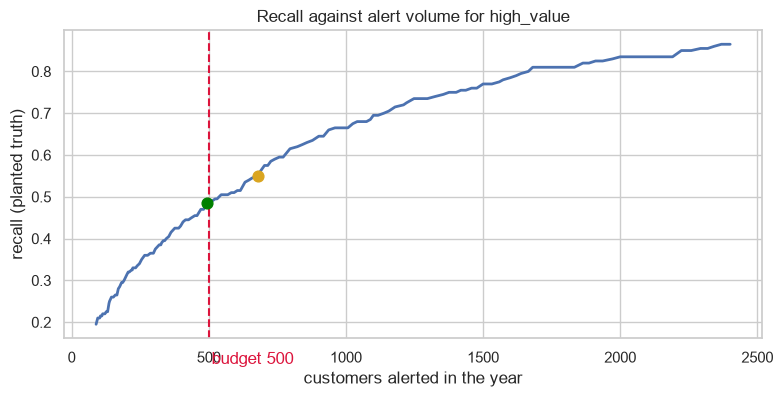

best within 500: threshold £95,838 -> 493 alerts, recall 48.5%, precision 19.7%
today £75,000        -> 679 alerts, recall 55.0%, precision 16.2%


In [4]:
BUDGET = 500
grid = np.geomspace(20_000, 300_000, 160)
sweep = pd.DataFrame([backtest.evaluate_rule(pop, {**rule, "threshold": float(t)}) for t in grid])
feasible = sweep[sweep.alerts <= BUDGET]
best = feasible.loc[feasible.recall.idxmax()]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sweep.alerts, sweep.recall, lw=2)
ax.axvline(BUDGET, ls="--", c="crimson"); ax.text(BUDGET + 10, 0.1, f"budget {BUDGET}", color="crimson")
ax.scatter([best.alerts], [best.recall], s=60, zorder=3, c="green")
today = pd.Series(backtest.evaluate_rule(pop, rule))   # the registered rule itself, not the nearest grid point
ax.scatter([today.alerts], [today.recall], s=60, zorder=3, c="goldenrod")
ax.set(xlabel="customers alerted in the year", ylabel="recall (planted truth)",
       title="Recall against alert volume for high_value")
plt.show()
print(f"best within {BUDGET}: threshold £{best.threshold:,.0f} -> {best.alerts} alerts, recall {best.recall:.1%}, precision {best.precision:.1%}")
print(f"today £{today.threshold:,.0f}        -> {today.alerts} alerts, recall {today.recall:.1%}, precision {today.precision:.1%}")

## Exercise 4 — selection bias: what a SAR-only backtest would report

In a real bank the only labels are outcomes on **alerted** customers. The customers the rule never alerted have no label,
so their misses are invisible. Compare what that view reports with the truth the planted population gives us.

In [5]:
labels = pop.labels()
top = pop.max_amount_by_customer()
alerted = {c for c, a in top.items() if a > rule["threshold"]}
tp = sum(labels[c] for c in alerted)
true_fn = sum(v for c, v in labels.items() if c not in alerted)

pd.DataFrame({
    "SAR-only view": {"precision": tp / len(alerted), "recall": tp / (tp + 0), "missed cases seen": 0},
    "planted truth": {"precision": tp / len(alerted), "recall": tp / (tp + true_fn), "missed cases seen": true_fn},
}).T.style.format({"precision": "{:.1%}", "recall": "{:.1%}"})

,precision,recall,missed cases seen
SAR-only view,16.2%,100.0%,0.000000
planted truth,16.2%,55.0%,90.000000


Precision agrees, because both views see the alerted customers. Recall doesn't: the SAR-only view reports **100%** because it has
no way to count a miss. That gap is selection bias, and the reason a regulator asks how you know what you're missing.

## Exercise 5 — a below-the-line sample

The fix is to look where the rule didn't: review a **random sample of non-alerted customers**, count the true cases, and scale up.
Watch the estimate and its 95% (Wilson) interval tighten as the sample grows.

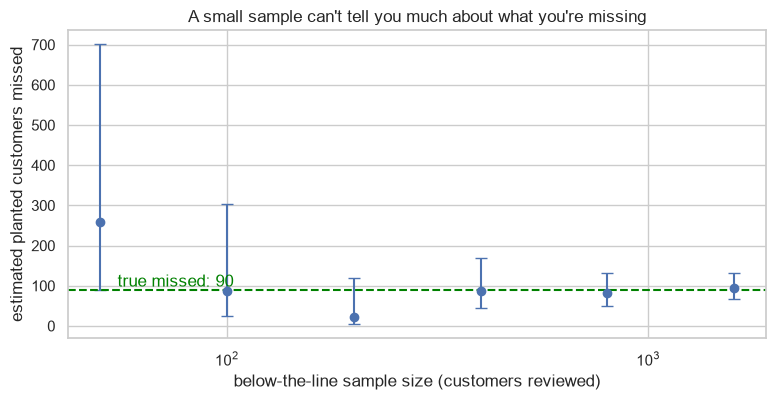

,sample,found,est_missed,missed_lo,missed_hi,est_recall
0,50,3,259.3,89.1,700.7,0.3
1,100,2,86.4,23.8,302.5,0.6
2,200,1,21.6,3.8,120.0,0.8
3,400,8,86.4,43.9,168.4,0.6
4,800,15,81.0,49.2,132.7,0.6
5,1600,35,94.5,68.1,130.8,0.5


In [6]:
rng = np.random.default_rng(7)
below = np.array(sorted(c for c in labels if c not in alerted))
rows = []
for n in (50, 100, 200, 400, 800, 1600):
    sample = rng.choice(below, size=n, replace=False)
    k = int(sum(labels[c] for c in sample))
    ci = binomtest(k, n).proportion_ci(method="wilson")
    est_missed = k / n * len(below)
    rows.append({"sample": n, "found": k, "est_missed": est_missed,
                 "missed_lo": ci.low * len(below), "missed_hi": ci.high * len(below),
                 "est_recall": tp / (tp + est_missed) if tp + est_missed else None})
est = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(est["sample"], est.est_missed, yerr=[est.est_missed - est.missed_lo, est.missed_hi - est.est_missed],
            fmt="o", capsize=4)
ax.axhline(true_fn, ls="--", c="green"); ax.text(55, true_fn + 8, f"true missed: {true_fn}", color="green")
ax.set(xscale="log", xlabel="below-the-line sample size (customers reviewed)", ylabel="estimated planted customers missed",
       title="A small sample can't tell you much about what you're missing")
plt.show()
est.round(1)

Small samples find very few true cases, so their intervals span almost anything. Only at a few hundred reviews does the estimate
say something useful. That cost is real, and it belongs in the tuning paper's **method** section (week 9).

## Exercise 6 — coverage by scenario

The backtest reports recall per planted scenario. TM-SIM v1 plants one, so the two numbers agree today.
The breakdown exists so that a second scenario (week 5 onward) can't hide inside an average.

In [7]:
pd.DataFrame(hv["coverage_by_scenario"]).T

,caught,planted,recall
value_spike,110.0,200.0,0.55


## Your answers (the curriculum's success criteria)

1. **Which threshold maximises detection within 500 alerts, and what does it give up against today?** Use Exercise 3.

    *…*

2. **What would a SAR-only backtest have told you about `high_value`, and why is it wrong?** Use Exercise 4.

    *…*

3. **How many below-the-line reviews would you ask for, and why that many?** Use Exercise 5.

    *…*